In [1]:
# compute coreference metrics

# for each doc: tanh (avg chain size / num chains)
# averaged across docs

In [2]:
from pathlib import Path
import json
import pandas as pd
import numpy as np

In [3]:
MODELS = ['human', 'claude45', 'gpt4o', 'internvl3', 'llama4scout', 'qwen3vl']
PROMPTS = ['original', 'large']
COREF_DIR = Path('/mimer/NOBACKUP/groups/naiss2025-22-1187/coherence-driven-humans/models/linkappend/data-out/conll_to_json')


In [4]:
def load_jsonlines(filepath):
    documents = []
    with open(filepath, 'r') as f:
        for line in f:
            documents.append(json.loads(line))
    return documents

def clean_human_original_data(doc):
    # human original data has [SENT] in the end, need to remove it, an artefact from some processing
    if len(doc['sentences']) > 0:
        last_sent = doc['sentences'][-1]
        if len(last_sent) >= 3 and last_sent[-3:] == ["[", "SENT", "]"]:
            doc['sentences'][-1] = last_sent[:-3]
            num_tokens_before_last = sum(len(sent) for sent in doc['sentences'][:-1])
            removed_token_start = num_tokens_before_last + len(last_sent) - 3
            new_clusters = []
            for cluster in doc['clusters']:
                new_mentions = [m for m in cluster if m[0] < removed_token_start]
                if new_mentions:
                    new_clusters.append(new_mentions)
            doc['clusters'] = new_clusters
    return doc

def normalize_story_id(raw_id):
    """Extract a plain int story_id from formats like 2926, '2926', 'story_2926', 'doc_2926_seed42'."""
    s = str(raw_id).replace('story_', '')
    parts = s.split('_')
    if len(parts) >= 2 and parts[0] == 'doc':
        s = parts[1]
    try:
        return int(float(s))
    except (ValueError, TypeError):
        return None

def compute_coref_metrics(doc):
    clusters = doc['clusters']
    num_chains = len(clusters)
    chain_sizes = [len(cluster) for cluster in clusters]
    avg_chain_size = np.mean(chain_sizes) if chain_sizes else 0
    epsilon = 0.01
    raw_ratio = avg_chain_size / (num_chains + epsilon) if num_chains > 0 else 0
    coref_ratio = np.tanh(raw_ratio)
    return {
        'num_chains': num_chains,
        'avg_chain_size': avg_chain_size,
        'coref_ratio': coref_ratio
    }

In [5]:
def load_coref_data():
    all_data = []
    for model in MODELS:
        for prompt in PROMPTS:
            if model == 'human' and prompt == 'large':
                seeds_to_load = ['42', '43', '44']
            else:
                seeds_to_load = ['42']
            for seed in seeds_to_load:
                filepath = COREF_DIR / f"{model}_{prompt}_seed{seed}_test_snapshots__local_json-nopound_pred.jsonlines"
                if not filepath.exists():
                    print(f"  Warning: {filepath.name} not found")
                    continue
                documents = load_jsonlines(filepath)
                for doc in documents:
                    if model == 'human' and prompt == 'original':
                        doc = clean_human_original_data(doc)
                    metrics = compute_coref_metrics(doc)
                    story_id = normalize_story_id(doc['doc_key'])
                    all_data.append({
                        'model': model, 'prompt': prompt, 'seed': seed,
                        'story_id': story_id, **metrics
                    })
    df = pd.DataFrame(all_data)
    df['story_id'] = df['story_id'].astype(int)
    return df

def prepare_coref_data(df):
    # averaging across human seeds
    results = []
    for model in MODELS:
        for prompt in PROMPTS:
            df_mp = df[(df['model'] == model) & (df['prompt'] == prompt)]
            if len(df_mp) == 0:
                continue
            if model == 'human' and prompt == 'large':
                df_avg = df_mp.groupby('story_id')[['num_chains', 'avg_chain_size', 'coref_ratio']].mean().reset_index()
                for _, row in df_avg.iterrows():
                    results.append({'model': model, 'prompt': prompt, 'story_id': row['story_id'],
                                    'num_chains': row['num_chains'], 'avg_chain_size': row['avg_chain_size'],
                                    'coref_ratio': row['coref_ratio']})
            else:
                df_seed42 = df_mp[df_mp['seed'] == '42']
                for _, row in df_seed42.iterrows():
                    results.append({'model': model, 'prompt': prompt, 'story_id': row['story_id'],
                                    'num_chains': row['num_chains'], 'avg_chain_size': row['avg_chain_size'],
                                    'coref_ratio': row['coref_ratio']})
    result = pd.DataFrame(results)
    result['story_id'] = result['story_id'].astype(int)
    return result

In [6]:
df_coref_raw = load_coref_data()
print(df_coref_raw.head())

   model    prompt seed  story_id  num_chains  avg_chain_size  coref_ratio
0  human  original   42     13683           2            7.50     0.998852
1  human  original   42     13596           5            3.60     0.616018
2  human  original   42     12423           4            4.75     0.828877
3  human  original   42     12358           2            6.50     0.996899
4  human  original   42     11719           2            6.00     0.994905


In [7]:
df_coref = prepare_coref_data(df_coref_raw)
print(df_coref.head())

   model    prompt  story_id  num_chains  avg_chain_size  coref_ratio
0  human  original     13683         2.0            7.50     0.998852
1  human  original     13596         5.0            3.60     0.616018
2  human  original     12423         4.0            4.75     0.828877
3  human  original     12358         2.0            6.50     0.996899
4  human  original     11719         2.0            6.00     0.994905


In [8]:
df_coref

,model,prompt,story_id,num_chains,avg_chain_size,coref_ratio
0,human,original,13683,2.0,7.500000,0.998852
1,human,original,13596,5.0,3.600000,0.616018
2,human,original,12423,4.0,4.750000,0.828877
3,human,original,12358,2.0,6.500000,0.996899
4,human,original,11719,2.0,6.000000,0.994905
...,...,...,...,...,...,...
715,qwen3vl,large,1111,6.0,6.000000,0.760894
716,qwen3vl,large,723,6.0,5.333333,0.710112
717,qwen3vl,large,4797,4.0,2.500000,0.553520
718,qwen3vl,large,6111,5.0,4.200000,0.684920


In [9]:
coref_agg = (
    df_coref.groupby(['model', 'prompt'])
    .agg(
        num_chains=('num_chains', 'mean'),
        avg_chain_size=('avg_chain_size', 'mean'),
        coref_ratio_mean=('coref_ratio', 'mean'),
        coref_ratio_std=('coref_ratio', 'std'),
        count=('coref_ratio', 'count')
    )
    .reset_index()
)

In [10]:
coref_agg

,model,prompt,num_chains,avg_chain_size,coref_ratio_mean,coref_ratio_std,count
0,claude45,large,7.366667,4.975587,0.589139,0.186850,60
1,claude45,original,6.900000,4.607905,0.582792,0.181004,60
2,gpt4o,large,5.433333,4.348545,0.660918,0.197311,60
3,gpt4o,original,5.883333,4.729590,0.647946,0.210240,60
4,human,large,6.205556,5.332454,0.678780,0.137480,60
5,human,original,3.800000,4.666290,0.773725,0.186228,60
6,internvl3,large,7.333333,4.582437,0.560120,0.192798,60
7,internvl3,original,7.050000,5.263807,0.631249,0.182304,60
8,llama4scout,large,5.866667,4.348888,0.633780,0.207720,60
9,llama4scout,original,4.866667,5.428265,0.730055,0.233890,60


In [11]:
# num chains - num of coref chains in a document, more chains -> more distinct entities
# avg chain size - avg num of mentions per chain, higher value -> entities are re-mentioned more often

# coref ratio - squashed between 0 and 1, chain size / num of chains + small epsilon (for when there are no chains, to prevent division by zero)
# values near 1: few chains but each has many mentions, the text focuses on a small set of entities and refers back to them repeatedly
# values near 0: many chains but each has few mentions, the text introduces many entities but does not sustain reference to them

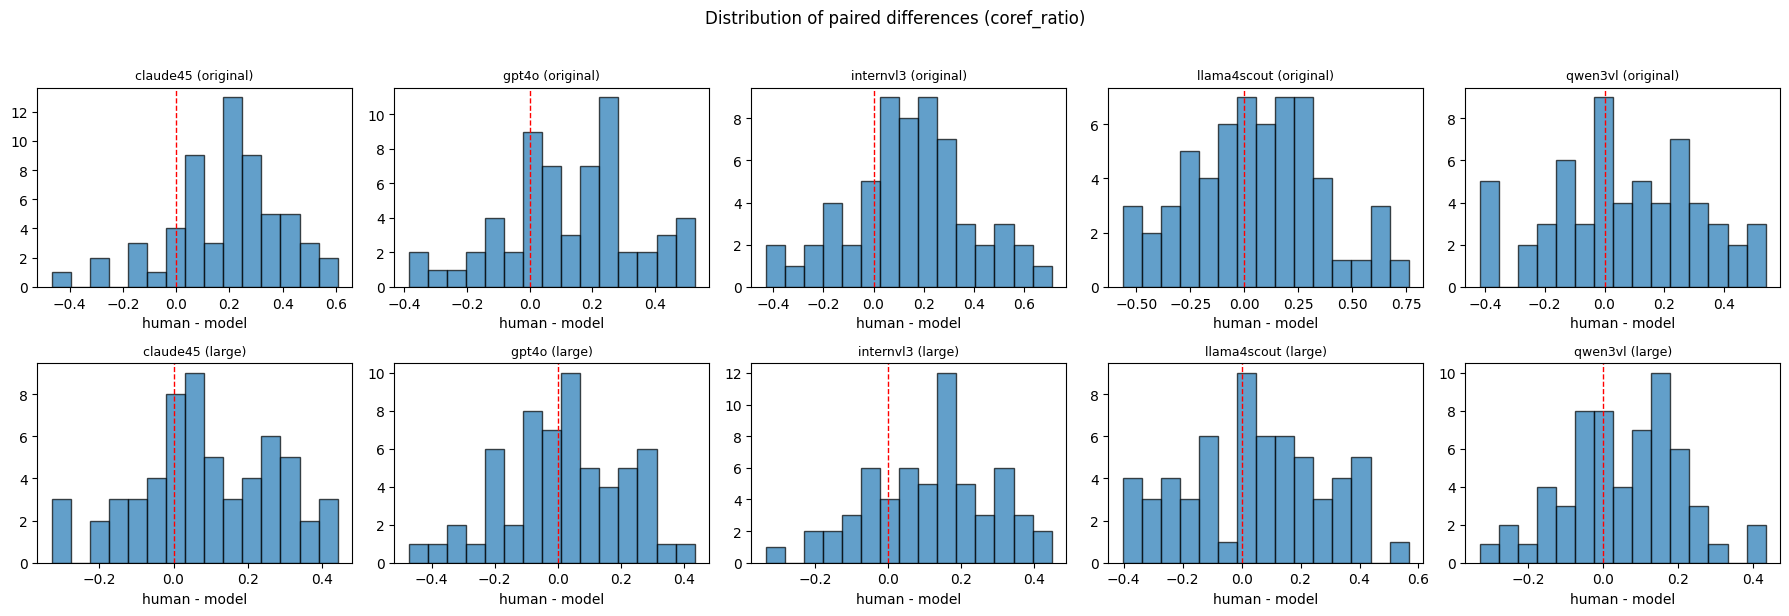

In [12]:
# visualising the distribution of ratio values, differences between humans and each of the models
# it's a check to run t-test, need to see if the differences form a roughly normal distribution

import matplotlib.pyplot as plt

fig, axes = plt.subplots(len(PROMPTS), len(MODELS) - 1, figsize=(18, 6), squeeze=False)

for i, prompt in enumerate(PROMPTS):
    df_human = df_coref[(df_coref['model'] == 'human') & (df_coref['prompt'] == prompt)].set_index('story_id')
    col = 0
    for model in MODELS:
        if model == 'human':
            continue
        df_model = df_coref[(df_coref['model'] == model) & (df_coref['prompt'] == prompt)].set_index('story_id')
        common_ids = df_human.index.intersection(df_model.index)
        
        diffs = df_human.loc[common_ids, 'coref_ratio'].values - df_model.loc[common_ids, 'coref_ratio'].values
        
        ax = axes[i][col]
        ax.hist(diffs, bins=15, edgecolor='black', alpha=0.7)
        ax.axvline(0, color='red', linestyle='--', linewidth=1)
        ax.set_title(f"{model} ({prompt})", fontsize=9)
        ax.set_xlabel('human - model')
        col += 1

plt.suptitle('Distribution of paired differences (coref_ratio)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

In [13]:
from scipy.stats import ttest_rel

# Paired t-test per prompt, paired by story_id
# Models vs Humans
# do VLMs produce stories with a different coreference density than humans?
# do VLMs re-refer to story entities differently than a human would?

for prompt in PROMPTS:
    print(f"--- Prompt: {prompt} ---")
    df_human = df_coref[(df_coref['model'] == 'human') & (df_coref['prompt'] == prompt)].set_index('story_id')
    for model in MODELS:
        if model == 'human':
            continue
        df_model = df_coref[(df_coref['model'] == model) & (df_coref['prompt'] == prompt)].set_index('story_id')
        
        # align by story_id
        common_ids = df_human.index.intersection(df_model.index)
        if len(common_ids) == 0:
            print(f"  {model}: no common story_ids")
            continue
        
        human_vals = df_human.loc[common_ids, 'coref_ratio'].values
        model_vals = df_model.loc[common_ids, 'coref_ratio'].values
        
        stat, p = ttest_rel(human_vals, model_vals)

        direction = "model > human" if np.mean(model_vals) > np.mean(human_vals) else "model < human"
        print(f"  {model:15s}  t={stat:.3f}  p={p:.4f}  n={len(common_ids)}  ({direction})")
    print()

--- Prompt: original ---
  claude45         t=6.904  p=0.0000  n=60  (model < human)
  gpt4o            t=4.596  p=0.0000  n=60  (model < human)
  internvl3        t=4.600  p=0.0000  n=60  (model < human)
  llama4scout      t=1.118  p=0.2680  n=60  (model < human)
  qwen3vl          t=2.221  p=0.0302  n=60  (model < human)

--- Prompt: large ---
  claude45         t=3.779  p=0.0004  n=60  (model < human)
  gpt4o            t=0.719  p=0.4751  n=60  (model < human)
  internvl3        t=5.473  p=0.0000  n=60  (model < human)
  llama4scout      t=1.459  p=0.1498  n=60  (model < human)
  qwen3vl          t=2.749  p=0.0079  n=60  (model < human)



In [14]:
# overall, many VLMs re-refer less than humans, llama4scout is an outlier

In [15]:
# Paired t-test per prompt, paired by story_id
# Original vs Large prompt
# do VLMs re-refer to story entities differently than a human would?

for model in MODELS:
    df_orig = df_coref[(df_coref['model'] == model) & (df_coref['prompt'] == 'original')].set_index('story_id')
    df_large = df_coref[(df_coref['model'] == model) & (df_coref['prompt'] == 'large')].set_index('story_id')
    
    common_ids = df_orig.index.intersection(df_large.index)
    if len(common_ids) == 0:
        print(f"  {model}: no common story_ids")
        continue
    
    orig_vals = df_orig.loc[common_ids, 'coref_ratio'].values
    large_vals = df_large.loc[common_ids, 'coref_ratio'].values
    
    stat, p = ttest_rel(orig_vals, large_vals)
    direction = "large > original" if np.mean(large_vals) > np.mean(orig_vals) else "large < original"
    print(f"  {model:15s}  t={stat:.3f}  p={p:.4f}  n={len(common_ids)}  ({direction})")

  human            t=3.847  p=0.0003  n=60  (large < original)
  claude45         t=-0.281  p=0.7795  n=60  (large > original)
  gpt4o            t=-0.497  p=0.6208  n=60  (large > original)
  internvl3        t=3.139  p=0.0026  n=60  (large < original)
  llama4scout      t=2.259  p=0.0276  n=60  (large < original)
  qwen3vl          t=3.280  p=0.0017  n=60  (large < original)


In [16]:
# overall, humans are very affected by the prompt change, significant decrease with the large prompt
# for several models, same behaviour is observed
# interestingly, coref_ratio of closed models is not affected by the prompt change

In [17]:
corefdata_path = Path('./analysis_data/coreference/')
corefdata_path.mkdir(parents=True, exist_ok=True)

df_coref_raw.to_csv(corefdata_path / 'coref_metrics_raw.csv', index=False)
df_coref.to_csv(corefdata_path / 'coref_metrics.csv', index=False)
coref_agg.to_csv(corefdata_path / 'coref_metrics_agg.csv', index=False)